In [2]:
import json
import os
import random
from copy import deepcopy
from scoring_service.HumanityScorer import scorer

# --- Configuration ---
DATA_DIR = "data"
# MODEL_SAVE_PATH = "models/offline_rl_model.pth"

# Simulation Hyperparameters
TARGET_HUMAN_COUNT = int(random.random() * 20) + 80   # Between 80-100  # Number of "real" human users to simulate
TARGET_BOT_COUNT = random.choice([0, 20, 50, 100, 200])  # Number of bot users to simulate (for DoS)
SIMULATION_STEP_SECONDS = 10  # How often the RL agent is called (matches frontend)
SESSION_CHUNK_SIZE = int(SIMULATION_STEP_SECONDS * 1000)  # In milliseconds

REWARDS = {}
conf = {
    "human": {
        "predicted": {
            "human": 0,
            "bot": 0
        }
    },
    "bot": {
        "predicted": {
            "human": 0,
            "bot": 0
        }
    }
}

In [3]:
def update_human_bot_population(human_count=None, bot_count=None):
    global TARGET_HUMAN_COUNT
    global TARGET_BOT_COUNT
    global conf

    TARGET_HUMAN_COUNT = human_count if human_count is not None else int(random.random() * 20) + 80      # Between 80-100
    TARGET_BOT_COUNT = bot_count if bot_count is not None else random.choice([0, 20, 50, 100, 200, 1000])  # One of the choices
    conf["human"]["predicted"]["human"] = 0
    conf["human"]["predicted"]["bot"] = 0
    conf["bot"]["predicted"]["human"] = 0
    conf["bot"]["predicted"]["bot"] = 0


def get_humanity_score(mouse_movement):
    """Calls the external humanity score ML model."""
    if not mouse_movement:
        # print(type(mouse_movement), mouse_movement)
        # print("Invalid mouse movement...")
        return None
    # Format for the ML model
    formatted_movements = [[m['x'], m['y']] for m in mouse_movement]
    try:
        prediction = scorer.predict(formatted_movements)
        # print(prediction)
        return prediction
    except Exception as e:
        print(f"Humanity score predictor connection error: {e}")
        return 0.5  # Return neutral score on error

def load_session_data(data_dir):
    """Loads all human and bot raw data files."""
    human_sessions = []
    bot_sessions = []
    print(f"Loading raw session data from {data_dir}...")
    for filename in os.listdir(data_dir):
        if not filename.endswith('.json'): continue
        filepath = os.path.join(data_dir, filename)
        try:
            with open(filepath, 'r') as f:
                data = json.load(f)
            if filename.startswith('human'):
                human_sessions.append(data)
            elif filename.startswith('bot'):
                bot_sessions.append(data)
        except Exception as e:
            print(f"Warning: Could not load or parse {filename}. Error: {e}")

    print(f"Loaded {len(human_sessions)} human sessions and {len(bot_sessions)} bot sessions.")
    if not human_sessions or not bot_sessions:
        print("Error: Not enough data to run simulation. Please run bot simulator and browse site.")
        exit()
    return human_sessions, bot_sessions


def perturb_mouse_data(movements):
    """Creates a 'new' user by slightly altering existing mouse data."""
    if not movements: return []
    # Add small random noise to each coordinate
    noise_x = random.randint(-5//5, 5//5)
    noise_y = random.randint(-5//5, 5//5)
    return [{**m, 'x': m['x'] + noise_x, 'y': m['y'] + noise_y, 'timestamp': m['timestamp']} for m in movements]


# def get_session_chunks(session_data, chunk_size_ms):
#     """Splits a full session's mouse data into 10-second (step) chunks."""
#     start_time = session_data['timestamps']['start']
#     movements = session_data.get('mouse_movements', [])
#     if not movements: return [[]]  # Return one empty chunk

#     chunks = []
#     current_chunk = []
#     chunk_end_time = start_time + chunk_size_ms

#     for move in movements:
#         if move['timestamp'] <= chunk_end_time:
#             current_chunk.append(move)
#         else:
#             chunks.append(current_chunk)
#             # Handle multiple empty steps
#             while move['timestamp'] > chunk_end_time + chunk_size_ms:
#                 chunks.append([])
#                 chunk_end_time += chunk_size_ms

#             current_chunk = [move]
#             chunk_end_time += chunk_size_ms

#     chunks.append(current_chunk)  # Add the last chunk
#     return chunks

def get_session_chunks(session_data, chunk_size_ms, target_chunks_size=12):
    """Splits a full session's mouse data into 10-second (step) chunks."""
    start_time = session_data['timestamps']['start']
    movements = session_data.get('mouse_movements', [])
    if not movements: return [[]]  # Return one empty chunk

    chunks = []
    current_chunk = []
    chunk_end_time = start_time + chunk_size_ms

    for move in movements:
        if move['timestamp'] <= chunk_end_time:
            current_chunk.append(move)
        else:
            chunks.append(current_chunk)
            if len(chunks) == target_chunks_size:
                return chunks
            # Handle multiple empty steps
            while move['timestamp'] > chunk_end_time + chunk_size_ms:
                chunks.append([])
                if len(chunks) == target_chunks_size:
                    return chunks
                chunk_end_time += chunk_size_ms

            current_chunk = [move]
            chunk_end_time += chunk_size_ms

    chunks.append(current_chunk)  # Add the last chunk
    if len(chunks) < target_chunks_size:
        chunks = chunks + get_session_chunks(session_data, chunk_size_ms, target_chunks_size=target_chunks_size - len(chunks))
    return chunks

class SimulatedUser:
    """Represents a single concurrent user (bot or human) in the simulation."""

    def __init__(self, base_session_data, is_bot):
        self.is_bot = is_bot
        self.client_id = f"{'bot' if is_bot else 'human'}_{random.randint(10000, 99999)}"
        self.captchas_solved = 0
        self.last_captcha_solved = -1
        self.done = False  # Is this user's session over?
        self.last_humanity_score = None
        self.average_humanity_score = 0.5
        self.n_humanity_score = 0

        # *** NEW: Assign a "strength" to each bot ***
        # This is the max threat level (0-9) the bot can "beat"
        # A threat level of 10 will *always* kill the bot.
        if self.is_bot:
            self.bot_strength = random.randint(0, 9)
        else:
            self.bot_strength = None  # Humans don't have a strength

        # Perturb and chunk the data to create a new, unique session
        perturbed_movements = perturb_mouse_data(base_session_data.get('mouse_movements', []))
        perturbed_session = {**base_session_data, 'mouse_movements': perturbed_movements}
        self.session_chunks = get_session_chunks(perturbed_session, SESSION_CHUNK_SIZE)
        self.current_chunk_index = 0

    def get_step_data(self):
        """Gets the mouse data for the current 10-second step."""
        if self.done or self.current_chunk_index >= len(self.session_chunks):
            self.done = True
            return None  # This user has finished their session

        chunk = self.session_chunks[self.current_chunk_index]
        self.current_chunk_index += 1
        return chunk
    
    def update_stats(self, h_score):
        if h_score is not None:
            self.last_humanity_score = h_score
            self.average_humanity_score = (self.average_humanity_score * self.n_humanity_score + h_score) / (self.n_humanity_score + 1)
            self.n_humanity_score += 1


    def reset_session(self):
        """Called when a bot is 'killed'."""
        self.captchas_solved = 0
        self.done = True

In [4]:
import math

def calculate_reward(user, threat_level):
    """
    Refined reward function for balancing Security vs. UX.
    Weights are normalized so that one 'Happy Human' is roughly 
    equivalent to one 'Caught Bot'.
    """
    reward = 0
    done = False
    
    # Constants for tuning
    MAX_REWARD = 50.0        # Baseline for a 'Perfect' action
    LEAKAGE_PENALTY = -150.0 # Bot got through (Critical Failure)
    FRICTION_BASE = 2.0      # Sensitivity to human annoyance
    
    if user.is_bot:
        if threat_level > user.bot_strength:
            # Bot CAUGHT
            # We want the lowest threat level that still beats the bot.
            # Overkill penalty: (threat_level - strength) 
            overkill = (threat_level - user.bot_strength)
            reward = MAX_REWARD - (overkill * 2.0) 
            done = True
            user.reset_session()
        else:
            # Bot LEAKED
            # Penalty scales with how much the bot 'outsmarted' the system
            gap = user.bot_strength - threat_level
            reward = LEAKAGE_PENALTY - (gap * 5.0)
            user.captchas_solved += 1
            
    else:
        # HUMAN logic
        if threat_level == 0:
            # Perfect score for zero friction
            reward = MAX_REWARD
        else:
            # Non-linear frustration: Level 1 is okay, Level 10 is infuriating.
            # Using an exponential penalty for human annoyance.
            frustration = math.pow(FRICTION_BASE, threat_level)
            reward = (MAX_REWARD / 2.0) - frustration
            
        user.captchas_solved += 1

        # Check if human gave up (Simulated patience)
        if threat_level == 10 or random.random() * (threat_level - 6) > 0.5:
            done = True # Human abandoned site due to high friction

    return reward, done

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

class FeatureNN(nn.Module):
    def __init__(self, input_dim=5, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim)
        )

    def forward(self, x):
        return self.net(x)

class DeepContextualBandit:
    def __init__(self, num_arms=11, context_dim=5, embed_dim=64, alpha=1.0, lr=1e-3):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.num_arms = num_arms
        self.alpha = alpha

        # neural network embedding
        self.feature_nn = FeatureNN(context_dim, embed_dim).to(self.device)
        self.optimizer = optim.Adam(self.feature_nn.parameters(), lr=lr)

        # UCB "linear head" parameters
        self.embed_dim = embed_dim
        self.As = [torch.eye(embed_dim).to(self.device) for _ in range(num_arms)]
        self.bs = [torch.zeros(embed_dim).to(self.device) for _ in range(num_arms)]

    def select_action(self, context):
        """
        Get UCB scores for each arm and pick best.
        context: torch.Tensor shape (context_dim,)
        """
        z = self.feature_nn(context.to(self.device))  # embed

        best_arm = None
        best_score = -float('inf')

        with torch.no_grad():
            for a in range(self.num_arms):
                A = self.As[a]
                b = self.bs[a]

                invA = torch.linalg.inv(A)
                theta_hat = invA @ b  # linear estimate

                mean = z @ theta_hat
                # UCB uncertainty
                unc = self.alpha * torch.sqrt((z @ invA) @ z)
                score = mean + unc

                if score > best_score:
                    best_score = score
                    best_arm = a

        return best_arm

    def update(self, context, action, reward):
        """
        Update linear head and train features with supervised signal.
        """
        context = context.to(self.device)
        reward = torch.tensor(reward, dtype=torch.float32, device=self.device)

        # get feature
        z = self.feature_nn(context)

        # ----------- Update linear head (NO GRAD) -----------
        with torch.no_grad():
            z_detached = z.detach()
            # update linear model for chosen arm
            A = self.As[action]
            b = self.bs[action]

            self.As[action] = A + torch.outer(z_detached, z_detached)
            self.bs[action] = b + reward * z_detached
        # # update linear model for chosen arm
        # A = self.As[action]
        # b = self.bs[action]

        # self.As[action] = A + torch.outer(z, z)
        # self.bs[action] = b + reward * z
        
        # Optional: train neural network to regress reward
        # Use current UCB arm predictor as pseudo target
        pred = (z @ torch.linalg.inv(self.As[action]) @ self.bs[action])
        loss = (pred - reward).pow(2)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def load(self, filepath):
        checkpoint = torch.load(filepath)
        self.feature_nn.load_state_dict(checkpoint["feature_nn"])
        self.optimizer.load_state_dict(checkpoint["optimizer"])
        self.As = checkpoint["As"]
        self.bs = checkpoint["bs"]
        self.num_arms = checkpoint["num_arms"]
        self.embed_dim = checkpoint["embed_dim"]
        self.alpha = checkpoint["alpha"]
        print(f"Model loaded successfully from {filepath}.")

    def save(self, filepath="linucb_model_0.pt"):
        checkpoint = {
            'feature_nn': self.feature_nn.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            "As": [A.cpu() for A in self.As],
            "bs": [b.cpu() for b in self.bs],
            "num_arms": self.num_arms,
            "embed_dim": self.embed_dim,
            "alpha": self.alpha
        }

        torch.save(checkpoint, filepath)
        print("Offline model saved.")

In [ ]:
# bandit = DeepContextualBandit(num_arms=11, context_dim=5)

# for episode in range(15):
#     print(f"Current epoch: {episode + 1}")

#     base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)
#     update_human_bot_population()
#     episode_reward = 0

#     print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
#     active_users = []
#     for _ in range(TARGET_HUMAN_COUNT):
#         active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
#     for _ in range(TARGET_BOT_COUNT):
#         active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))

#     random.shuffle(active_users)

#     while active_users:
#         server_total_users = len(active_users)
#         next_active_users = []

#         for user in active_users:
#             mouse_data = user.get_step_data()
#             humanity_score = get_humanity_score(mouse_data)
#             if humanity_score is None:
#                 # print(humanity_score, user.average_humanity_score, "handling")
#                 if user.average_humanity_score is None:
#                     humanity_score = 0.5
#                 else:
#                     humanity_score = user.average_humanity_score
#             else:
#                 user.last_humanity_score = humanity_score
#                 if user.average_humanity_score is None:
#                     user.average_humanity_score = humanity_score
#                 else:
#                     user.average_humanity_score = (user.average_humanity_score * user.n_humanity_score + humanity_score) / (user.n_humanity_score + 1)
#                 user.n_humanity_score += 1

#             conf["bot" if user.is_bot else "human"]["predicted"]["bot" if humanity_score >= .5 else "human"] += 1

#             context = [
#                 humanity_score,
#                 user.average_humanity_score if user.average_humanity_score is not None else 0.5,
#                 user.captchas_solved,
#                 user.last_captcha_solved,   # client_req_rate_per_min, avg_h_score
#                 server_total_users
#             ]
#             context = torch.Tensor(context)

#             action = bandit.select_action(context)

#             reward, done = calculate_reward(user, action)  # hidden

#             print(action, reward)
#             episode_reward += reward

#             bandit.update(context, action, reward)

#             if not user.done:
#                 next_active_users.append(user)
        
#         active_users = next_active_users

#     print(conf, episode_reward, episode_reward / (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT))

#     REWARDS[episode+1] = {
#         "reward": episode_reward,
#         "population": TARGET_HUMAN_COUNT + TARGET_BOT_COUNT,
#         "conf": deepcopy(conf)
#     }

Current epoch: 1
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 91 humans, 100 bots
0 -16.0
1 -15.0
2 90.0
3 6
4 3
5 -14.0
6 90.0
7 75.0
8 -9
9 -12
10 95.0
6 -3
10 75.0
2 -12.0
7 -6
10 50.0
10 -15
3 90.0
3 6
4 3
8 95.0
8 -9
5 0
9 85.0
9 -12
0 -10.0
1 -14.0
7 -6
4 95.0
4 -13.0
5 75.0
5 0
7 -6
6 85.0
6 90.0
6 70.0
6 -3
0 -14.0
1 -13.0
0 15
0 -17.0
0 -11.0
1 -18.0
0 -11.0
0 -11.0
0 -10.0
0 15
0 15
0 -14.0
0 -12.0
0 15
0 15
0 -16.0
0 -13.0
1 12
1 12
1 12
1 -17.0
1 12
1 12
1 12
1 12
1 -11.0
1 12
1 12
1 -13.0
1 95.0
1 12
1 -13.0
1 -18.0
1 12
1 12
1 12
1 -12.0
1 -11.0
1 12
1 12
1 12
1 12
1 -11.0
1 -12.0
1 -18.0
1 12
1 12
1 12
1 12
1 -17.0
1 12
1 12
1 12
1 12
1 12
1 12
1 12
1 12
1 12
1 -12.0
1 12
1 -16.0
1 -14.0
1 12
1 12
1 12
1 -11.0
1 12
1 12
1 -18.0
1 -17.0
1 12
1 -15.0
1 -10.0
1 -17.0
1 12
1 -14.0
1 12
1 -16.0
1 12
1 -18.0
1 12
1 12
1 12
1 -14.0
1 95.0
1 -13.0
1 12
1 -15.0
1 -15.0
1 12
1 -10.0
1 -16.0
1 12
1 -11.0
1 -11.0
1 12
1 -11

In [6]:
import torch
import random
import numpy as np
from copy import deepcopy

# Configuration Constants
HUMAN_BUFFER = []
BOT_BUFFER = []
BUFFER_SIZE = 2000
BATCH_SIZE = 64
TRAIN_FREQUENCY = 30  # Train every 10 global steps

REWARDS_LOG = []
BOT_REWARD = []
HUMAN_REWARD = []


def normalize_context(context_list):
    """Ensures all context features are in a similar 0-1 range for NN stability."""
    # Context indices: 0: score, 1: avg_score, 2: solved, 3: last_solved, 4: server_total
    # Solved counts can be high, so we squash them with tanh or log
    ctx = np.array(context_list, dtype=np.float32)
    ctx[2] = np.tanh(ctx[2] / 10.0)  # Solved count normalization
    ctx[3] = np.tanh(ctx[3] / 10.0)  # Last solved normalization
    ctx[4] = np.tanh(ctx[4] / 200.0) # Server load normalization
    return torch.Tensor(ctx)

def train_balanced_step(bandit):
    """Samples 50% humans and 50% bots to prevent mode collapse."""
    if len(HUMAN_BUFFER) < BATCH_SIZE // 2 or len(BOT_BUFFER) < BATCH_SIZE // 2:
        return # Not enough data yet

    # Sample equal amounts
    h_batch = random.sample(HUMAN_BUFFER, BATCH_SIZE // 2)
    b_batch = random.sample(BOT_BUFFER, BATCH_SIZE // 2)
    
    combined_batch = h_batch + b_batch
    random.shuffle(combined_batch)
    
    # Perform update using the bandit's internal training method
    # Note: You might need to adapt this based on your bandit's specific API
    for ctx, act, rew in combined_batch:
        bandit.update(ctx, act, rew)
        

bandit = DeepContextualBandit(num_arms=11, context_dim=5)

base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.


In [13]:
bandit.load("./other_models/linucb/models/4/model_-31.pt")

Model loaded successfully from ./other_models/linucb/models/4/model_-31.pt.


In [14]:
# --- MAIN LOOP ---
global_step_counter = 0

best_score = -30

for episode in range(20):
    print(f"\n--- Epoch: {episode + 1} ---")
    # if episode < 3:
    #     update_human_bot_population(bot_count=0)
    # elif episode < 6:
    #     update_human_bot_population(bot_count=20)
    # else:
    #     update_human_bot_population() # Sets TARGET_HUMAN_COUNT, TARGET_BOT_COUNT

    update_human_bot_population()    

    print(f"Population ::: Human: {TARGET_HUMAN_COUNT} | Bot: {TARGET_BOT_COUNT}")
    episode_reward = 0
    episode_h_step_counter = 0
    episode_b_step_counter = 0
    episode_human_reward = 0
    episode_bot_reward = 0
    
    # Initialize session population
    active_users = []
    # Load and wrap your human/bot sessions
    for _ in range(TARGET_HUMAN_COUNT):
        active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
    for _ in range(TARGET_BOT_COUNT):
        active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))

    random.shuffle(active_users)

    while active_users:
        server_total_users = len(active_users)
        next_active_users = []

        for user in active_users:
            global_step_counter += 1
            
            # 1. Perception: Get humanity score
            mouse_data = user.get_step_data()
            h_score = get_humanity_score(mouse_data)
            
            # Update user's internal tracking
            user.update_stats(h_score) # Logic moved to a helper for cleanliness

            if h_score is None:
                h_score = user.average_humanity_score

            # 2. Context Building
            raw_context = [
                h_score,
                user.average_humanity_score,
                user.captchas_solved,
                user.last_captcha_solved,
                server_total_users
            ]
            context = normalize_context(raw_context)

            # 3. Action Selection
            # Exploration logic (epsilon-greedy) is usually inside select_action
            action = bandit.select_action(context)

            # 4. Environment Feedback
            reward, done = calculate_reward(user, action) 
            episode_reward += reward

            if user.is_bot:
                BOT_REWARD.append(reward)
                episode_bot_reward += reward
                episode_b_step_counter += 1
            else:
                HUMAN_REWARD.append(reward)
                episode_human_reward += reward
                episode_h_step_counter += 1
            REWARDS_LOG.append(reward)

            # 5. Balanced Memory Storage
            target_buffer = BOT_BUFFER if user.is_bot else HUMAN_BUFFER
            target_buffer.append((context, action, reward))
            
            # Keep buffer size manageable
            if len(target_buffer) > BUFFER_SIZE:
                target_buffer.pop(0)

            # 6. Balanced Training Trigger
            if global_step_counter % TRAIN_FREQUENCY == 0:
                train_balanced_step(bandit)

            if not user.done:
                next_active_users.append(user)
        
        active_users = next_active_users

    cur_score = (episode_human_reward / episode_h_step_counter) + (episode_bot_reward / episode_b_step_counter if episode_b_step_counter else 0)
    if episode_b_step_counter > 0 and cur_score > best_score:
        best_score = cur_score
        bandit.save(filepath="./other_models/linucb/models/4/best_model.pt")
        print(f"Saved Best Model with Score = {best_score:.2f}!")

    if (episode + 1) % 10 == 0:
        bandit.save(filepath=f"./other_models/linucb/models/4/model_{cur_score:.0f}.pt")
        print(f"Saved Model with Score = {cur_score:.2f} at episode {episode + 1}")
            

    # Metrics logging...
    avg_rew = episode_reward / (episode_h_step_counter + episode_b_step_counter)   # (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    avg_human_rew = episode_human_reward / episode_h_step_counter
    avg_bot_rew = episode_bot_reward / episode_b_step_counter if episode_b_step_counter else 0
    print(f"Total Reward: {episode_reward:.2f} | Avg: {avg_rew:.2f} | Avg Human: {avg_human_rew:.2f} | Avg Bot: {avg_bot_rew:.2f}")
    
    avg_session_rew = episode_reward / (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    avg_h_session_rew = episode_human_reward / (TARGET_HUMAN_COUNT)
    avg_b_session_rew = episode_bot_reward / TARGET_BOT_COUNT if TARGET_BOT_COUNT else 0
    print(f"Average Session Rewards::: Mean: {avg_session_rew:.2f} | Human: {avg_h_session_rew:.2f} | Bot: {avg_b_session_rew:.2f}")


--- Epoch: 1 ---
Population ::: Human: 81 | Bot: 50
Offline model saved.
Saved Best Model with Score = -19.57!
Total Reward: 28747.00 | Avg: 25.31 | Avg Human: 31.31 | Avg Bot: -50.88
Average Session Rewards::: Mean: 219.44 | Human: 407.04 | Bot: -84.46

--- Epoch: 2 ---
Population ::: Human: 91 | Bot: 100
Total Reward: 10121.00 | Avg: 7.52 | Avg Human: 14.56 | Avg Bot: -43.88
Average Session Rewards::: Mean: 52.99 | Human: 189.34 | Bot: -71.09

--- Epoch: 3 ---
Population ::: Human: 83 | Bot: 1000
Offline model saved.
Saved Best Model with Score = -14.94!
Total Reward: -16388.00 | Avg: -7.09 | Avg Human: -13.21 | Avg Bot: -1.73
Average Session Rewards::: Mean: -15.13 | Human: -171.76 | Bot: -2.13

--- Epoch: 4 ---
Population ::: Human: 86 | Bot: 0
Total Reward: 44938.00 | Avg: 40.19 | Avg Human: 40.19 | Avg Bot: 0.00
Average Session Rewards::: Mean: 522.53 | Human: 522.53 | Bot: 0.00

--- Epoch: 5 ---
Population ::: Human: 88 | Bot: 0
Total Reward: 46892.00 | Avg: 40.99 | Avg Human: 

In [ ]:
    # # Metrics logging...
    # avg_rew = episode_reward / (episode_h_step_counter + episode_b_step_counter)   # (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    # avg_human_rew = episode_human_reward / episode_h_step_counter
    # avg_bot_rew = episode_bot_reward / episode_b_step_counter
    # print(f"Total Reward: {episode_reward:.2f} | Avg: {avg_rew:.2f} | Avg Human: {avg_human_rew:.2f} | Avg Bot: {avg_bot_rew:.2f}")

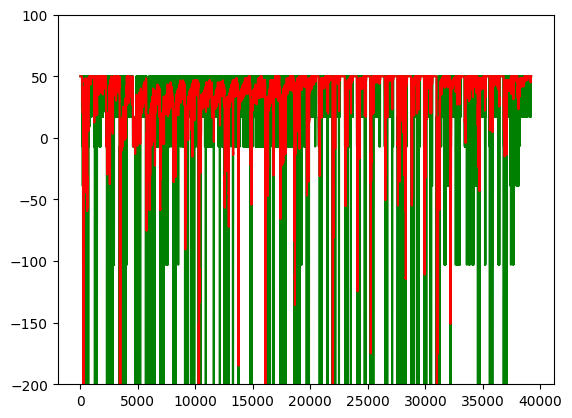

In [38]:
import matplotlib.pyplot as plt

# ---- Moving average ----
window_size = 20
moving_avg = []
for i in range(len(HUMAN_REWARD)):
    if i < window_size:
        moving_avg.append(np.mean(HUMAN_REWARD[:i+1]))
    else:
        moving_avg.append(np.mean(HUMAN_REWARD[i-window_size+1:i+1]))

plt.plot(HUMAN_REWARD, color="green")
plt.plot(moving_avg, color="red")
plt.ylim(-200, 100)
plt.show()

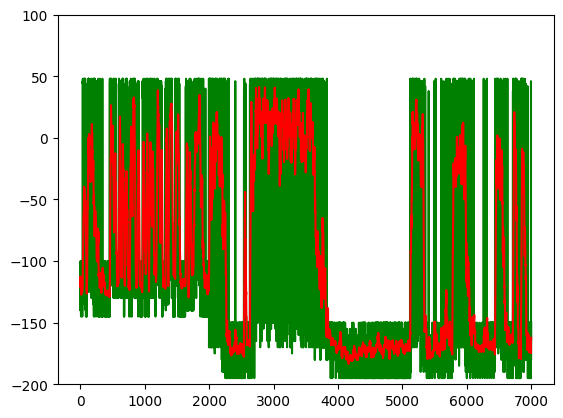

In [39]:
import matplotlib.pyplot as plt

# ---- Moving average ----
window_size = 20
moving_avg = []
for i in range(len(BOT_REWARD)):
    if i < window_size:
        moving_avg.append(np.mean(BOT_REWARD[:i+1]))
    else:
        moving_avg.append(np.mean(BOT_REWARD[i-window_size+1:i+1]))

plt.plot(BOT_REWARD, color="green")
plt.plot(moving_avg, color="red")
plt.ylim(-200, 100)
plt.show()

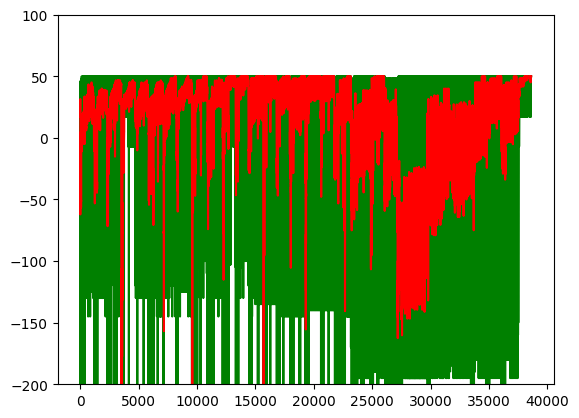

In [40]:
import matplotlib.pyplot as plt

# ---- Moving average ----
window_size = 20
moving_avg = []
for i in range(len(REWARDS_LOG)):
    if i < window_size:
        moving_avg.append(np.mean(REWARDS_LOG[:i+1]))
    else:
        moving_avg.append(np.mean(REWARDS_LOG[i-window_size+1:i+1]))

plt.plot(REWARDS_LOG, color="green")
plt.plot(moving_avg, color="red")
plt.ylim(-200, 100)
plt.show()

In [ ]:
# filepath = "./linucb/models/model_0.pt"

# checkpoint = {
#     'feature_nn': bandit.feature_nn.state_dict(),
#     'optimizer': bandit.optimizer.state_dict(),
#     "As": [A.cpu() for A in bandit.As],
#     "bs": [b.cpu() for b in bandit.bs],
#     "num_arms": bandit.num_arms,
#     "embed_dim": bandit.embed_dim,
#     "alpha": bandit.alpha
# }

# torch.save(checkpoint, filepath)
# print("Offline model saved.")

Offline model saved.


In [15]:
bandit.save(filepath="./other_models/linucb/models/model_2_0.pt")

Offline model saved.
